In [3]:
!pip install --upgrade seaborn

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import random
import math

In [5]:
print(sns.__version__)

0.13.2


In [6]:
import warnings
warnings.filterwarnings('ignore')

# Data Analysis and Cleaning

In [7]:
pers_diet_recom_path = "/kaggle/input/Personalized_Diet_Recommendations.csv"

In [8]:
original_df = pd.read_csv(pers_diet_recom_path)
df = original_df.copy()
df

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Chronic_Disease,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,...,Protein_Intake,Carbohydrate_Intake,Fat_Intake,Preferred_Cuisine,Food_Aversions,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats,Recommended_Meal_Plan
0,P00001,56,Other,163,66,24.84,NaN,175,75,219,...,105,179,143,Western,NaN,2150,108,139,145,High-Protein Diet
1,P00002,69,Female,171,114,38.99,NaN,155,72,208,...,69,315,75,Mediterranean,NaN,1527,74,266,80,Balanced Diet
2,P00003,46,Female,172,119,40.22,NaN,137,101,171,...,183,103,148,Western,Sweet,2359,180,145,143,High-Protein Diet
3,P00004,32,Female,197,118,30.41,NaN,148,91,258,...,135,371,120,Western,NaN,2858,137,378,135,High-Protein Diet
4,P00005,60,Female,156,109,44.79,Hypertension,160,109,260,...,167,298,48,Indian,Spicy,1937,166,317,56,High-Protein Diet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,P04996,42,Female,172,99,33.46,NaN,115,78,279,...,59,356,64,Western,Spicy,2869,70,402,68,Low-Carb Diet
4996,P04997,39,Female,155,61,25.39,NaN,110,97,258,...,119,164,112,Indian,NaN,1138,131,213,107,Low-Carb Diet
4997,P04998,48,Female,165,61,22.41,Diabetes,113,82,183,...,50,351,41,Mediterranean,Spicy,2893,40,380,34,Low-Carb Diet
4998,P04999,34,Other,151,82,35.96,Heart Disease,105,75,248,...,50,397,131,Asian,Salty,2201,56,367,128,Low-Fat Diet


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_ID                5000 non-null   object 
 1   Age                       5000 non-null   int64  
 2   Gender                    5000 non-null   object 
 3   Height_cm                 5000 non-null   int64  
 4   Weight_kg                 5000 non-null   int64  
 5   BMI                       5000 non-null   float64
 6   Chronic_Disease           2957 non-null   object 
 7   Blood_Pressure_Systolic   5000 non-null   int64  
 8   Blood_Pressure_Diastolic  5000 non-null   int64  
 9   Cholesterol_Level         5000 non-null   int64  
 10  Blood_Sugar_Level         5000 non-null   int64  
 11  Genetic_Risk_Factor       5000 non-null   object 
 12  Allergies                 1503 non-null   object 
 13  Daily_Steps               5000 non-null   int64  
 14  Exercise

In [10]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,Blood_Sugar_Level,Daily_Steps,Exercise_Frequency,Sleep_Hours,Caloric_Intake,Protein_Intake,Carbohydrate_Intake,Fat_Intake,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,48.805600,174.244000,84.36620,28.353134,133.982400,89.735800,224.297800,159.33020,8458.922800,2.978200,7.019680,2347.350200,124.781800,248.590000,84.522600,2046.236000,129.287000,248.328600,89.029400
std,17.906991,14.229173,20.18103,8.297745,26.216215,17.283025,42.918923,52.14943,3742.408853,2.001431,1.716133,659.880146,43.280037,86.535683,37.495091,671.380142,43.914252,91.152909,38.336083
min,18.000000,150.000000,50.00000,12.630000,90.000000,60.000000,150.000000,70.00000,2004.000000,0.000000,4.000000,1200.000000,50.000000,100.000000,20.000000,725.000000,40.000000,50.000000,10.000000
25%,34.000000,162.000000,67.00000,21.850000,111.000000,75.000000,187.000000,114.00000,5278.750000,1.000000,5.600000,1777.000000,87.000000,175.000000,52.000000,1478.000000,92.000000,173.000000,56.000000
50%,49.000000,174.000000,84.00000,27.640000,133.000000,90.000000,224.000000,160.00000,8452.000000,3.000000,7.000000,2350.500000,126.000000,249.000000,85.000000,2044.000000,129.000000,246.000000,89.000000
75%,64.000000,186.000000,102.00000,33.812500,157.000000,105.000000,261.000000,204.00000,11671.750000,5.000000,8.500000,2921.250000,162.000000,325.000000,116.000000,2621.000000,166.000000,324.000000,121.000000
max,79.000000,199.000000,119.00000,52.890000,179.000000,119.000000,299.000000,249.00000,14997.000000,6.000000,10.000000,3499.000000,199.000000,399.000000,149.000000,3372.000000,218.000000,447.000000,168.000000


In [11]:
df.nunique()

Patient_ID                  5000
Age                           62
Gender                         3
Height_cm                     50
Weight_kg                     70
BMI                         1800
Chronic_Disease                4
Blood_Pressure_Systolic       90
Blood_Pressure_Diastolic      60
Cholesterol_Level            150
Blood_Sugar_Level            180
Genetic_Risk_Factor            2
Allergies                      3
Daily_Steps                 4147
Exercise_Frequency             7
Sleep_Hours                   61
Alcohol_Consumption            2
Smoking_Habit                  2
Dietary_Habits                 4
Caloric_Intake              2026
Protein_Intake               150
Carbohydrate_Intake          300
Fat_Intake                   130
Preferred_Cuisine              4
Food_Aversions                 3
Recommended_Calories        2162
Recommended_Protein          177
Recommended_Carbs            388
Recommended_Fats             159
Recommended_Meal_Plan          4
dtype: int

In [12]:
df.shape

(5000, 30)

### Dropping Unnecessary Columns
During the preprocessing, we identified certain columns that were unnecessary for the analysis. One such column was **'Patient_ID'** which is an identifier and does not provide useful information. 

In [13]:
df.drop(columns=['Patient_ID'],inplace=True)

### Checking for Missing Values
The function isnull() returns a DataFrame of the same shape as df, with True for missing values (NaN) and False for non-missing values. The sum() function then counts the number of True values in each column, providing the total number of missing values per column.

In [14]:
df.isnull().sum()

Age                            0
Gender                         0
Height_cm                      0
Weight_kg                      0
BMI                            0
Chronic_Disease             2043
Blood_Pressure_Systolic        0
Blood_Pressure_Diastolic       0
Cholesterol_Level              0
Blood_Sugar_Level              0
Genetic_Risk_Factor            0
Allergies                   3497
Daily_Steps                    0
Exercise_Frequency             0
Sleep_Hours                    0
Alcohol_Consumption            0
Smoking_Habit                  0
Dietary_Habits                 0
Caloric_Intake                 0
Protein_Intake                 0
Carbohydrate_Intake            0
Fat_Intake                     0
Preferred_Cuisine              0
Food_Aversions              1225
Recommended_Calories           0
Recommended_Protein            0
Recommended_Carbs              0
Recommended_Fats               0
Recommended_Meal_Plan          0
dtype: int64

The features with NaN values are remove for the data frame

In [15]:
df.drop(columns=['Chronic_Disease','Allergies','Food_Aversions',],inplace=True)

### Duplicate Entry Check

In [16]:
df.duplicated().sum() 

0

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       5000 non-null   int64  
 1   Gender                    5000 non-null   object 
 2   Height_cm                 5000 non-null   int64  
 3   Weight_kg                 5000 non-null   int64  
 4   BMI                       5000 non-null   float64
 5   Blood_Pressure_Systolic   5000 non-null   int64  
 6   Blood_Pressure_Diastolic  5000 non-null   int64  
 7   Cholesterol_Level         5000 non-null   int64  
 8   Blood_Sugar_Level         5000 non-null   int64  
 9   Genetic_Risk_Factor       5000 non-null   object 
 10  Daily_Steps               5000 non-null   int64  
 11  Exercise_Frequency        5000 non-null   int64  
 12  Sleep_Hours               5000 non-null   float64
 13  Alcohol_Consumption       5000 non-null   object 
 14  Smoking_

### Label Encoding
The LabelEncoder converts each category in a categorical feature into a unique integer. For instance, 'Male' might be encoded as 0, 'Female' as 1, and 'Other' as 2. Label Encoding is necessary for machine learning models to process categorical data. By transforming these labels into numbers.

In [18]:
encoder= LabelEncoder()
df['Gender']= encoder.fit_transform(df['Gender'])
df['Genetic_Risk_Factor']= encoder.fit_transform(df['Genetic_Risk_Factor'])
df['Smoking_Habit']= encoder.fit_transform(df['Smoking_Habit'])
df['Dietary_Habits']= encoder.fit_transform(df['Dietary_Habits'])
df['Preferred_Cuisine']=encoder.fit_transform(df['Preferred_Cuisine'])
df['Recommended_Meal_Plan']= encoder.fit_transform(df['Recommended_Meal_Plan'])

## Data Visualization

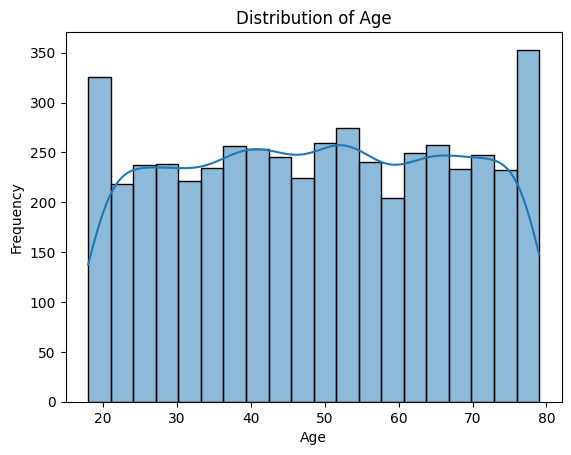

In [19]:
sns.histplot(df['Age'], bins=20, kde=True)  # kde=True adds a smooth density curve
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

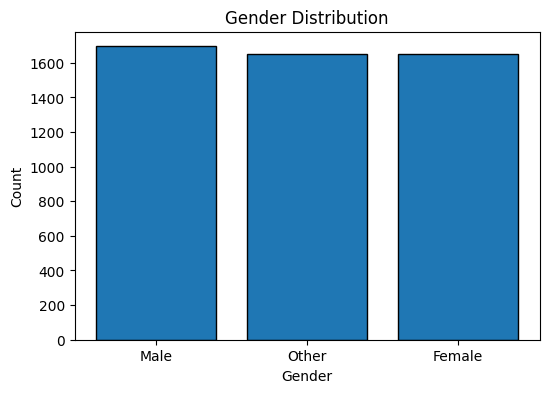

In [20]:
# Count occurrences of each gender
gender_counts = df['Gender'].value_counts()

# Define mapping for labels
gender_labels = {0: 'Male', 1: 'Female', 2: 'Other'}

# Plot bar chart with mapped labels
plt.figure(figsize=(6, 4))
plt.bar([gender_labels[g] for g in gender_counts.index], gender_counts.values, 
       edgecolor='black')

# Add title and labels
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')

# Show the plot
plt.show()

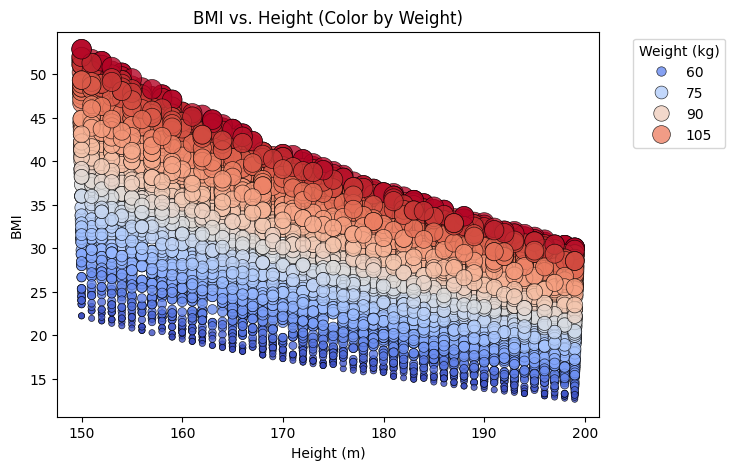

In [21]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=df['Height_cm'], y=df['BMI'], hue=df['Weight_kg'], size=df['Weight_kg'],
                palette='coolwarm', sizes=(20, 200), edgecolor='black', alpha=0.8)

plt.xlabel('Height (m)')
plt.ylabel('BMI')
plt.title('BMI vs. Height (Color by Weight)')
plt.legend(title='Weight (kg)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

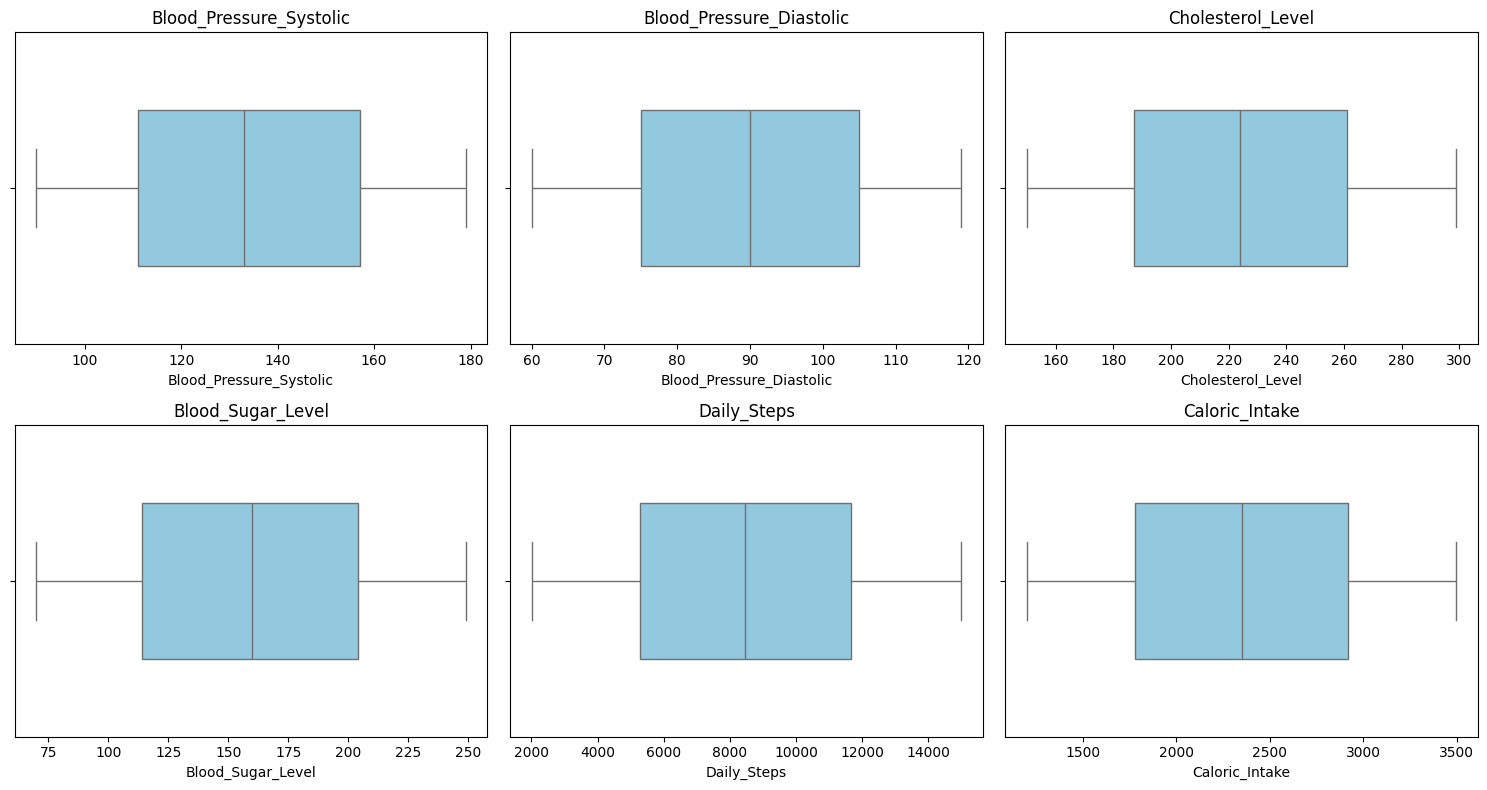

In [22]:
columns_to_plot = [
    'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 
    'Cholesterol_Level', 'Blood_Sugar_Level', 
    'Daily_Steps', 'Caloric_Intake'
]

# Create subplots
plt.figure(figsize=(15, 8))

for i, col in enumerate(columns_to_plot):
    plt.subplot(2, 3, i+1)  # Create a subplot for each variable
    sns.boxplot(data=df, x=col, color='skyblue', width=0.5)
    plt.title(f'{col}')


plt.tight_layout()
plt.show()

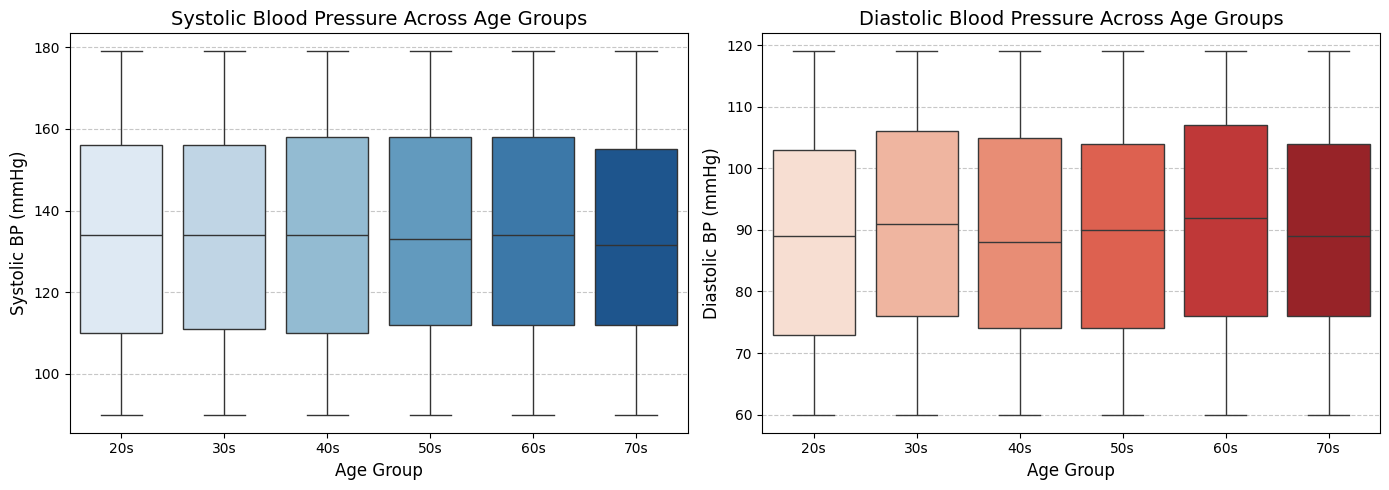

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Age vs Systolic BP
sns.boxplot(
    x=pd.cut(df['Age'], bins=[20, 30, 40, 50, 60, 70, 80], labels=['20s', '30s', '40s', '50s', '60s', '70s']),
    y=df['Blood_Pressure_Systolic'],
    palette='Blues',
    ax=axes[0]
)
axes[0].set_title("Systolic Blood Pressure Across Age Groups", fontsize=14)
axes[0].set_xlabel("Age Group", fontsize=12)
axes[0].set_ylabel("Systolic BP (mmHg)", fontsize=12)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Age vs Diastolic BP
sns.boxplot(
    x=pd.cut(df['Age'], bins=[20, 30, 40, 50, 60, 70, 80], labels=['20s', '30s', '40s', '50s', '60s', '70s']),
    y=df['Blood_Pressure_Diastolic'],
    palette='Reds',
    ax=axes[1]
)
axes[1].set_title("Diastolic Blood Pressure Across Age Groups", fontsize=14)
axes[1].set_xlabel("Age Group", fontsize=12)
axes[1].set_ylabel("Diastolic BP (mmHg)", fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

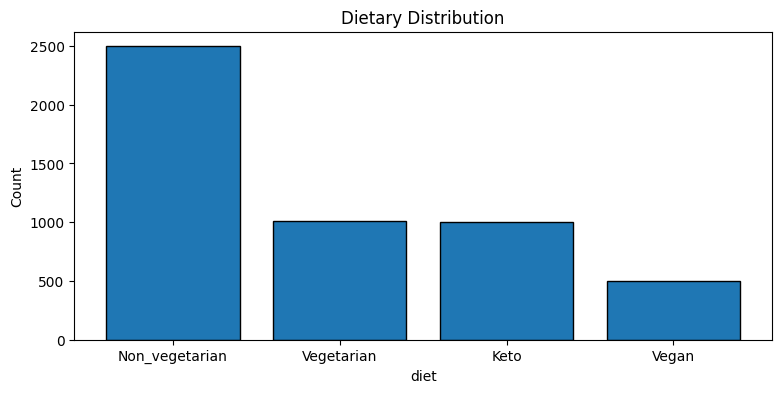

In [24]:
diet_habits= df['Dietary_Habits'].value_counts()

# Define mapping for labels
diet_labels = {0: 'Vegetarian', 1: 'Non_vegetarian', 2: 'Vegan',3:'Keto'}

# Plot bar chart with mapped labels
plt.figure(figsize=(9, 4))
plt.bar([diet_labels[g] for g in diet_habits.index], diet_habits.values, 
       edgecolor='black')

# Add title and labels
plt.title('Dietary Distribution')
plt.xlabel('diet')
plt.ylabel('Count')

# Show the plot
plt.show()

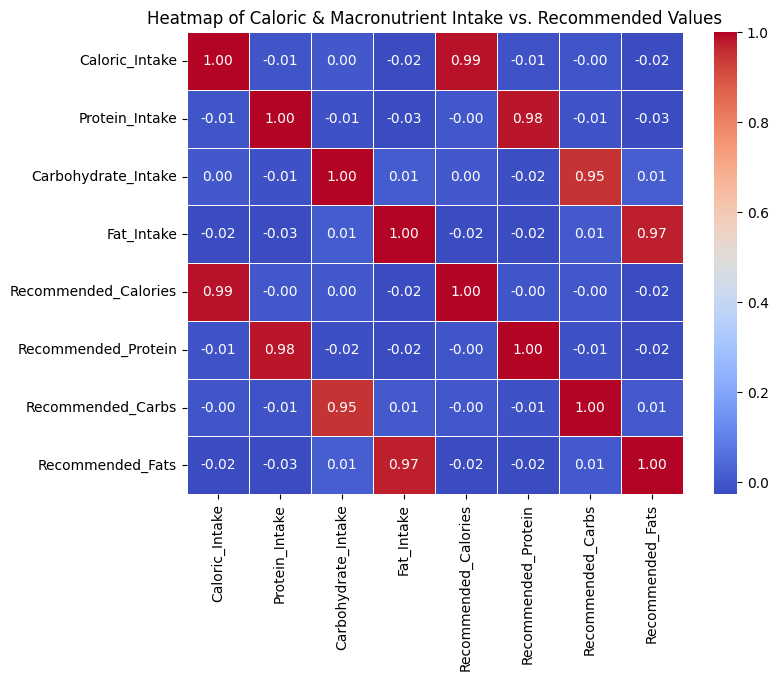

In [25]:
columns = [
    "Caloric_Intake", "Protein_Intake", "Carbohydrate_Intake", "Fat_Intake",
    "Recommended_Calories", "Recommended_Protein", "Recommended_Carbs", "Recommended_Fats"
]

#correlation matrix
corr_matrix = df[columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Caloric & Macronutrient Intake vs. Recommended Values")
plt.show()

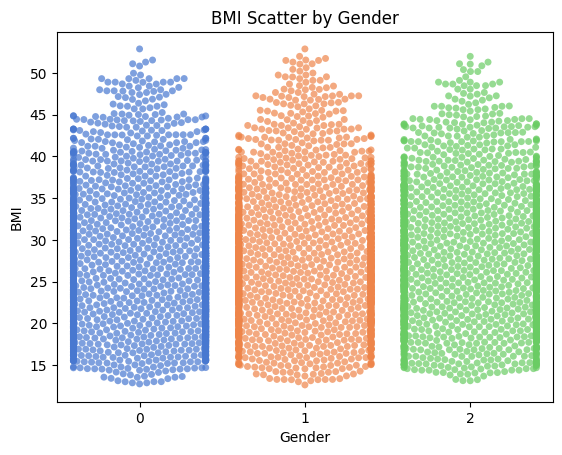

In [26]:
sns.swarmplot(x=df["Gender"], y=df["BMI"], palette="muted", alpha=0.7)
plt.xlabel("Gender")
plt.ylabel("BMI")
plt.title("BMI Scatter by Gender")
plt.show()

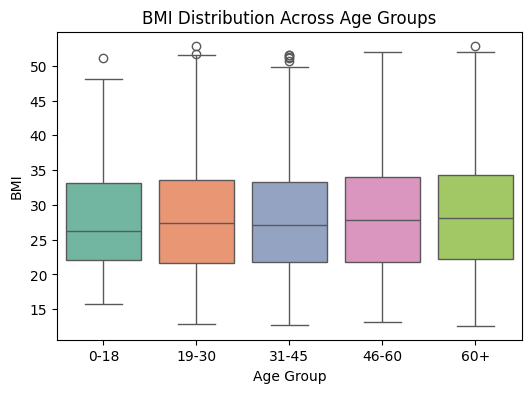

In [27]:
plt.figure(figsize=(6, 4))

## Using pd.cut() inside the boxplot function
sns.boxplot(x=pd.cut(df["Age"], bins=[0, 18, 30, 45, 60, 100], 
                      labels=["0-18", "19-30", "31-45", "46-60", "60+"]),
            y=df["BMI"], palette="Set2")

plt.xlabel("Age Group")
plt.ylabel("BMI")
plt.title("BMI Distribution Across Age Groups")
plt.show()

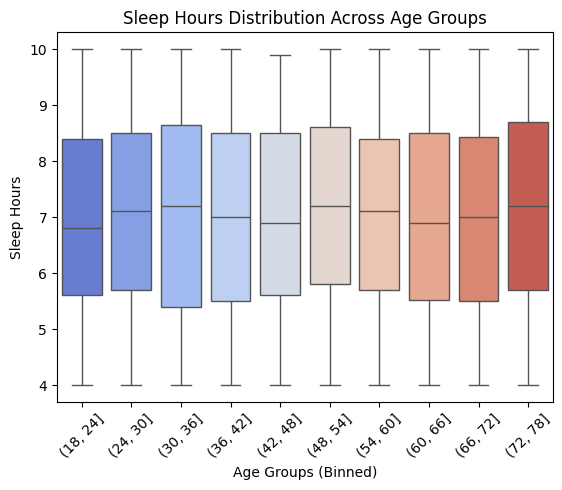

In [28]:
##Creating age bins dynamically in the plot
bins = list(range(int(df["Age"].min()), int(df["Age"].max()) + 1, (df["Age"].max() - df["Age"].min()) // 10))
sns.boxplot(x=pd.cut(df["Age"], bins=bins), y=df["Sleep_Hours"], palette="coolwarm")

plt.xlabel("Age Groups (Binned)")
plt.ylabel("Sleep Hours")
plt.title("Sleep Hours Distribution Across Age Groups")
plt.xticks(rotation=45)
plt.show()

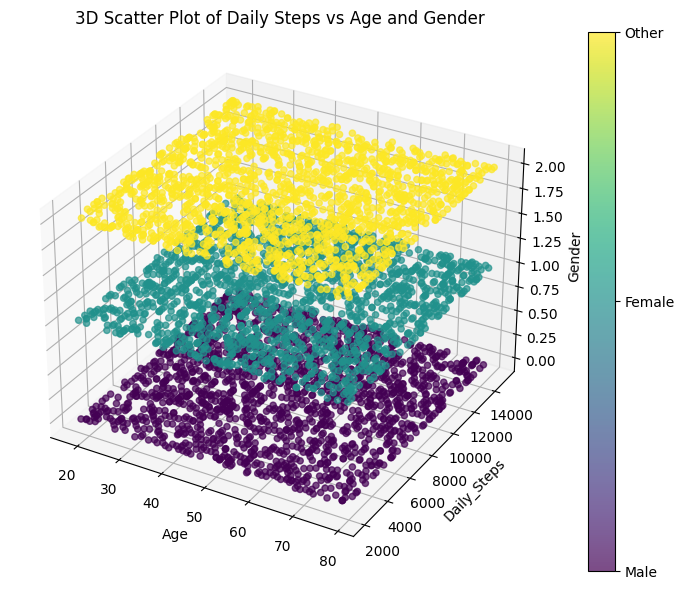

In [29]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['Age'], df['Daily_Steps'], df['Gender'], c=df['Gender'], cmap='viridis', alpha=0.7)

ax.set_xlabel('Age')
ax.set_ylabel('Daily_Steps')
ax.set_zlabel('Gender')

#Customizing the colorbar to show gender labels
cbar = plt.colorbar(ax.collections[0], ax=ax, orientation='vertical')
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(['Male', 'Female', 'Other'])

plt.title('3D Scatter Plot of Daily Steps vs Age and Gender')

plt.show()

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       5000 non-null   int64  
 1   Gender                    5000 non-null   int64  
 2   Height_cm                 5000 non-null   int64  
 3   Weight_kg                 5000 non-null   int64  
 4   BMI                       5000 non-null   float64
 5   Blood_Pressure_Systolic   5000 non-null   int64  
 6   Blood_Pressure_Diastolic  5000 non-null   int64  
 7   Cholesterol_Level         5000 non-null   int64  
 8   Blood_Sugar_Level         5000 non-null   int64  
 9   Genetic_Risk_Factor       5000 non-null   int64  
 10  Daily_Steps               5000 non-null   int64  
 11  Exercise_Frequency        5000 non-null   int64  
 12  Sleep_Hours               5000 non-null   float64
 13  Alcohol_Consumption       5000 non-null   object 
 14  Smoking_

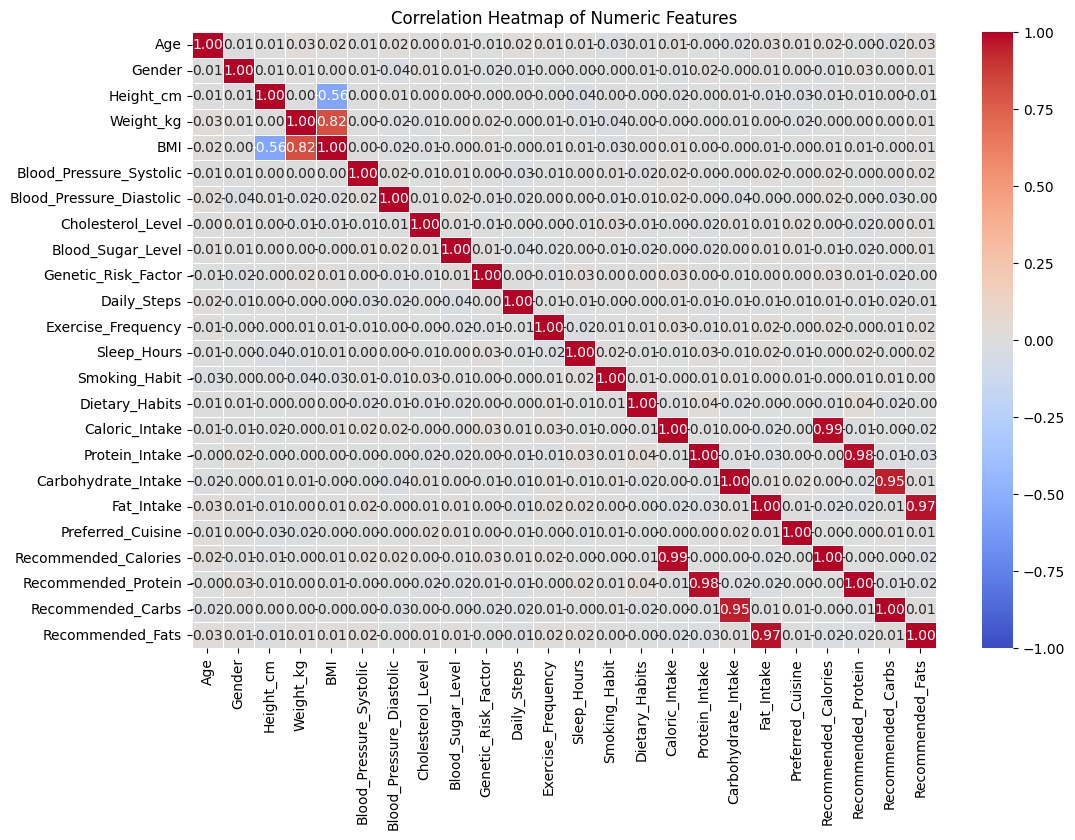

In [31]:
#numeric cols
df_numeric = df.select_dtypes(include=[float, int])

#correlation matrix calcualtaion
corr_matrix = df_numeric.iloc[:,:-1].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## Features given taken from Module A - Data Visulaization

### Removal of the features:
Reasons:
- Caloric_Intake, Protein_Intake, Carbohydrate_Intake and Fat_Intake were removed as these features are difficult for users to enter.
- Recommended_Calories, Recommended_Protein, Recommended_Carbs, Recommended_Fats were removed as they were prediction columns. These are out of scope of our current project.
- We choose BMI as input feature removing Height and Weight during model building as they were negatively and positevely correlated respectively. Thus, these donot offer importance as a feature.

## Selected Features
From an initial set of 30 features, we carefully filtered out 11 key features using various analytical methods and domain-specific reasoning. These features were selected to optimize diet recommendations based on health status, lifestyle, and nutritional needs. Below, we explain why each feature was chosen and its relevance to diet recommendation.

1. Age:
   Dietary needs change with age. Younger individuals require more calories for growth, while older adults need a balanced diet to maintain health and    prevent age-related diseases.
2. Gender:
   Men and women have different nutritional requirements due to differences in metabolism, muscle mass, and hormonal balance.   

3. BMI (Body Mass Index):
  BMI helps assess whether a person is underweight, normal weight, overweight, or obese. This determines calorie intake and macronutrient distribution    in the recommended diet.
4. Blood Pressure (Systolic & Diastolic):
   High blood pressure (hypertension) requires a diet low in sodium and rich in potassium, fiber, and healthy fats (DASH diet).Monitoring blood
   pressure  helps for diet recommendations accordingly.
5. Cholesterol Level:
   High cholesterol levels increase the risk of heart disease. A diet rich in fiber, healthy fats, and low in trans fats can be recommended for
   individuals with high cholesterol.
6. Blood Sugar Level:
    For individuals with diabetes or prediabetes, a diet low in refined sugars and high in complex carbohydrates and fiber is essential. Monitoring
   blood sugar levels helps in suggesting the right diet.
7. Daily Steps:
    Physical activity affects calorie needs. A sedentary person needs a different calorie intake compared to an active individual. More active people
   require higher energy intake to support their lifestyle.
8. Sleep Hours:
    Poor sleep can impact metabolism and hunger hormones, leading to unhealthy eating habits. 
9. Alcohol Consumption:
    Excessive alcohol consumption affects nutrient absorption and liver health. Individuals consuming alcohol frequently may need a diet rich in
    vitamins B and C to counteract deficiencies.
10. Smoking Habit
    Smoking depletes vitamin C and increases oxidative stress. A diet rich in antioxidants, vitamin C, and omega-3 fatty acids can be recommended to
    help reduce its harmful effects.
11. Dietary Habits
   Understanding a person’s current dietary habits (e.g., vegetarian, non-vegetarian, high sugar intake, etc.) helps in providing personalized and
   realistic diet recommendations that align with their preferences and lifestyle.

# Conversion of processed data into rule digestable format

In [32]:
features=['Age','Gender','Height_cm','Weight_kg','BMI','Blood_Pressure_Systolic','Blood_Pressure_Diastolic','Cholesterol_Level','Blood_Sugar_Level', 'Daily_Steps','Sleep_Hours','Alcohol_Consumption','Smoking_Habit','Dietary_Habits']
target_name = "Recommended_Meal_Plan"
len(features)

14

### Creating new dataframe from the given features only

In [33]:
df = original_df[features]
df

,Age,Gender,Height_cm,Weight_kg,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,Blood_Sugar_Level,Daily_Steps,Sleep_Hours,Alcohol_Consumption,Smoking_Habit,Dietary_Habits
0,56,Other,163,66,24.84,175,75,219,124,11452,7.6,No,Yes,Vegetarian
1,69,Female,171,114,38.99,155,72,208,72,12962,6.3,Yes,No,Vegetarian
2,46,Female,172,119,40.22,137,101,171,145,7898,9.9,No,No,Vegetarian
3,32,Female,197,118,30.41,148,91,258,235,6602,4.2,No,No,Vegetarian
4,60,Female,156,109,44.79,160,109,260,248,9810,9.0,No,No,Regular
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,42,Female,172,99,33.46,115,78,279,112,5723,6.5,No,No,Vegetarian
4996,39,Female,155,61,25.39,110,97,258,93,4786,7.2,Yes,No,Keto
4997,48,Female,165,61,22.41,113,82,183,151,5390,8.8,No,No,Regular
4998,34,Other,151,82,35.96,105,75,248,153,12887,7.0,No,Yes,Keto


In [34]:
for col in df.select_dtypes(include=['object']).columns:
    print(col)

Gender
Alcohol_Consumption
Smoking_Habit
Dietary_Habits


In [35]:
class RawtoTrain:
    def __init__(self, blood_pressure_mapping, cholestrol_mapping, blood_sugar_mapping):
        self.blood_pressure_mapping = blood_pressure_mapping
        self.cholestrol_mapping = cholestrol_mapping
        self.blood_sugar_mapping = blood_sugar_mapping

    
    def bmi_converter(self, height_cm: int, weight_kg: int):
        return (weight_kg * 10000) / height_cm ** 2

    
    def blood_pressure_converter(self, systolic: int, diastolic: int):
        if systolic < 90 or diastolic < 60:
            value = "Low"
        elif 90 <= systolic <= 129 and 60 <= diastolic <= 79:
            value = "Normal"
        elif systolic > 129 or diastolic > 79:
            value =  "High"
        else:
            value = "Normal"
        
        return value
        
   
    def cholesterol_converter(self, cholesterol_level: int):
        if cholesterol_level < 200:
            value = "Optimal"
        elif 200 <= cholesterol_level < 240:
            value = "Borderline"
        else:
            value = "High"
        
        #return self.cholestrol_mapping[value]
        return value

    
    def blood_sugar_converter(self, blood_sugar_level: int):
        if blood_sugar_level < 70:
            value = "Low"
        elif 70 <= blood_sugar_level <= 99:
            value = "Normal"
        else:  #blood_sugar_level >= 100
            value = "High"
        
        #return self.blood_pressure_mapping[value]
        return value
    
    def __drop_converted_features(self, df):
        columns_to_be_dropped = ["Blood_Pressure_Systolic", "Blood_Pressure_Diastolic","Cholesterol_Level", "Blood_Sugar_Level"]
        df = df.drop(columns= columns_to_be_dropped)
        return df

    def raw_to_train_feature_conv(self, df):
        '''
        Takes in the original dataframe and returns the transformed df that is ready to train.
        Convert df into user required data format
        i.e numerical data into categorical
        '''
        
        df["blood_pressure_converted"] = df.apply(lambda row: self.blood_pressure_converter(row["Blood_Pressure_Systolic"], row["Blood_Pressure_Diastolic"]), axis = 1)
        df["cholesterol_level_converted"] = df.apply(lambda row: self.cholesterol_converter(row["Cholesterol_Level"]), axis = 1)
        df["blood_sugar_level_converted"] = df.apply(lambda row: self.blood_sugar_converter(row["Blood_Sugar_Level"]), axis= 1)

        df = self.__drop_converted_features(df)
        
        return df

In [36]:
class RawtoTrainLabel:
    def __init__(self, single_column):
        self.label_to_index = {}
        self.index_to_label = {}
        self.single_column = single_column
        self.__create_mapping()
    
    def __create_mapping(self):
        unique_values = sorted(set(self.single_column))
        self.label_to_index = {unique_value : idx +1 for idx, unique_value in enumerate(unique_values)}
        self.index_to_label = {idx+ 1 : unique_value for idx, unique_value in enumerate(unique_values)}
    
    def convert_label_to_index(self, column):
        return [self.label_to_index[value] for value in column]

    def convert_index_to_label(self, column):
        return [self.index_to_label[value] for value in column]
    

class RawtoTrainLabelOneHot:
    def __init__(self, df, column_name, unique_values):
        self.df = df
        self.column_name = column_name
        self.unique_values = unique_values

    def convert_label_to_onehot(self):
        df = self.df
        new_columns = [self.column_name + "_" + unique_value for unique_value in self.unique_values]
        print(f"new columns list : {new_columns}")
        new_df = pd.DataFrame(0, index = np.arange(df.shape[0]), columns=new_columns)

        for idx, row in enumerate(df[self.column_name]):
            new_df_col_name = self.column_name + "_" + row
            new_df.loc[idx, new_df_col_name] = 1
        
        df.drop(columns=[self.column_name], inplace= True)
        
        # print("newdf ", new_df)
        # print("df", df)
        df = pd.concat([df, new_df], axis= 1)
        return df

In [37]:
blood_pressure_mapping = {
    "Low" : 1,
    "Normal" : 2,
    "High" : 2
}
cholestrol_mapping = {
    "Optimal" : 1,
    "Borderline" : 2,
    "High" : 3
}

blood_sugar_mapping = {
    "Low" : 1,
    "Normal": 2,
    "High": 3
}

In [38]:
raw_to_train = RawtoTrain(blood_pressure_mapping, cholestrol_mapping, blood_sugar_mapping)
df = raw_to_train.raw_to_train_feature_conv(df)
df

,Age,Gender,Height_cm,Weight_kg,BMI,Daily_Steps,Sleep_Hours,Alcohol_Consumption,Smoking_Habit,Dietary_Habits,blood_pressure_converted,cholesterol_level_converted,blood_sugar_level_converted
0,56,Other,163,66,24.84,11452,7.6,No,Yes,Vegetarian,High,Borderline,High
1,69,Female,171,114,38.99,12962,6.3,Yes,No,Vegetarian,High,Borderline,Normal
2,46,Female,172,119,40.22,7898,9.9,No,No,Vegetarian,High,Optimal,High
3,32,Female,197,118,30.41,6602,4.2,No,No,Vegetarian,High,High,High
4,60,Female,156,109,44.79,9810,9.0,No,No,Regular,High,High,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,42,Female,172,99,33.46,5723,6.5,No,No,Vegetarian,Normal,High,High
4996,39,Female,155,61,25.39,4786,7.2,Yes,No,Keto,High,High,Normal
4997,48,Female,165,61,22.41,5390,8.8,No,No,Regular,High,Optimal,High
4998,34,Other,151,82,35.96,12887,7.0,No,Yes,Keto,Normal,High,High


In [39]:
processed_df = df.copy()
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          5000 non-null   int64  
 1   Gender                       5000 non-null   object 
 2   Height_cm                    5000 non-null   int64  
 3   Weight_kg                    5000 non-null   int64  
 4   BMI                          5000 non-null   float64
 5   Daily_Steps                  5000 non-null   int64  
 6   Sleep_Hours                  5000 non-null   float64
 7   Alcohol_Consumption          5000 non-null   object 
 8   Smoking_Habit                5000 non-null   object 
 9   Dietary_Habits               5000 non-null   object 
 10  blood_pressure_converted     5000 non-null   object 
 11  cholesterol_level_converted  5000 non-null   object 
 12  blood_sugar_level_converted  5000 non-null   object 
dtypes: float64(2), int

### User enters the values that are present in the column of processed_df

In [40]:
df.drop(columns= ["Height_cm", "Weight_kg"], inplace= True)

## Label Conversion to indexes

In [41]:
# Before Conversion:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          5000 non-null   int64  
 1   Gender                       5000 non-null   object 
 2   BMI                          5000 non-null   float64
 3   Daily_Steps                  5000 non-null   int64  
 4   Sleep_Hours                  5000 non-null   float64
 5   Alcohol_Consumption          5000 non-null   object 
 6   Smoking_Habit                5000 non-null   object 
 7   Dietary_Habits               5000 non-null   object 
 8   blood_pressure_converted     5000 non-null   object 
 9   cholesterol_level_converted  5000 non-null   object 
 10  blood_sugar_level_converted  5000 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 429.8+ KB


In [42]:
for col in df.select_dtypes(include=['object']).columns:
    print(col , " => ", df[col].unique())

Gender  =>  ['Other' 'Female' 'Male']
Alcohol_Consumption  =>  ['No' 'Yes']
Smoking_Habit  =>  ['Yes' 'No']
Dietary_Habits  =>  ['Vegetarian' 'Regular' 'Keto' 'Vegan']
blood_pressure_converted  =>  ['High' 'Normal']
cholesterol_level_converted  =>  ['Borderline' 'Optimal' 'High']
blood_sugar_level_converted  =>  ['High' 'Normal']


In [43]:
## Custom dummies function:

column_name_unique_val_map = {
    "Gender" : ["Male", "Female", "Other"],
    "Alcohol_Consumption" : ["Yes", "No"],
    "Smoking_Habit" : ["Yes", "No"],
    "Dietary_Habits" : ["Regular", "Vegetarian", "Keto", "Vegan"],
    "blood_pressure_converted" : ["Low", "Normal", "High"],
    "cholesterol_level_converted" : ["Borderline", "Optimal", "High"],
    "blood_sugar_level_converted" : ["Low", "Normal", "High"]
}

for col_name, unique_val in column_name_unique_val_map.items():
    one_hot_encode = RawtoTrainLabelOneHot(df, column_name= col_name, unique_values= unique_val)
    df = one_hot_encode.convert_label_to_onehot()

df

new columns list : ['Gender_Male', 'Gender_Female', 'Gender_Other']
new columns list : ['Alcohol_Consumption_Yes', 'Alcohol_Consumption_No']
new columns list : ['Smoking_Habit_Yes', 'Smoking_Habit_No']
new columns list : ['Dietary_Habits_Regular', 'Dietary_Habits_Vegetarian', 'Dietary_Habits_Keto', 'Dietary_Habits_Vegan']
new columns list : ['blood_pressure_converted_Low', 'blood_pressure_converted_Normal', 'blood_pressure_converted_High']
new columns list : ['cholesterol_level_converted_Borderline', 'cholesterol_level_converted_Optimal', 'cholesterol_level_converted_High']
new columns list : ['blood_sugar_level_converted_Low', 'blood_sugar_level_converted_Normal', 'blood_sugar_level_converted_High']


,Age,BMI,Daily_Steps,Sleep_Hours,Gender_Male,Gender_Female,Gender_Other,Alcohol_Consumption_Yes,Alcohol_Consumption_No,Smoking_Habit_Yes,...,Dietary_Habits_Vegan,blood_pressure_converted_Low,blood_pressure_converted_Normal,blood_pressure_converted_High,cholesterol_level_converted_Borderline,cholesterol_level_converted_Optimal,cholesterol_level_converted_High,blood_sugar_level_converted_Low,blood_sugar_level_converted_Normal,blood_sugar_level_converted_High
0,56,24.84,11452,7.6,0,0,1,0,1,1,...,0,0,0,1,1,0,0,0,0,1
1,69,38.99,12962,6.3,0,1,0,1,0,0,...,0,0,0,1,1,0,0,0,1,0
2,46,40.22,7898,9.9,0,1,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
3,32,30.41,6602,4.2,0,1,0,0,1,0,...,0,0,0,1,0,0,1,0,0,1
4,60,44.79,9810,9.0,0,1,0,0,1,0,...,0,0,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,42,33.46,5723,6.5,0,1,0,0,1,0,...,0,0,1,0,0,0,1,0,0,1
4996,39,25.39,4786,7.2,0,1,0,1,0,0,...,0,0,0,1,0,0,1,0,1,0
4997,48,22.41,5390,8.8,0,1,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
4998,34,35.96,12887,7.0,0,0,1,0,1,1,...,0,0,1,0,0,0,1,0,0,1


In [44]:
#After Conversion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Age                                     5000 non-null   int64  
 1   BMI                                     5000 non-null   float64
 2   Daily_Steps                             5000 non-null   int64  
 3   Sleep_Hours                             5000 non-null   float64
 4   Gender_Male                             5000 non-null   int64  
 5   Gender_Female                           5000 non-null   int64  
 6   Gender_Other                            5000 non-null   int64  
 7   Alcohol_Consumption_Yes                 5000 non-null   int64  
 8   Alcohol_Consumption_No                  5000 non-null   int64  
 9   Smoking_Habit_Yes                       5000 non-null   int64  
 10  Smoking_Habit_No                        5000 non-null   int6

In [45]:
final_feature_names = df.columns
final_feature_names

Index(['Age', 'BMI', 'Daily_Steps', 'Sleep_Hours', 'Gender_Male',
       'Gender_Female', 'Gender_Other', 'Alcohol_Consumption_Yes',
       'Alcohol_Consumption_No', 'Smoking_Habit_Yes', 'Smoking_Habit_No',
       'Dietary_Habits_Regular', 'Dietary_Habits_Vegetarian',
       'Dietary_Habits_Keto', 'Dietary_Habits_Vegan',
       'blood_pressure_converted_Low', 'blood_pressure_converted_Normal',
       'blood_pressure_converted_High',
       'cholesterol_level_converted_Borderline',
       'cholesterol_level_converted_Optimal',
       'cholesterol_level_converted_High', 'blood_sugar_level_converted_Low',
       'blood_sugar_level_converted_Normal',
       'blood_sugar_level_converted_High'],
      dtype='object')

In [46]:
target_df = original_df[target_name]
target_df

0       High-Protein Diet
1           Balanced Diet
2       High-Protein Diet
3       High-Protein Diet
4       High-Protein Diet
              ...        
4995        Low-Carb Diet
4996        Low-Carb Diet
4997        Low-Carb Diet
4998         Low-Fat Diet
4999        Low-Carb Diet
Name: Recommended_Meal_Plan, Length: 5000, dtype: object

In [47]:
## Converting target column to index:
target_label_converter = RawtoTrainLabel(target_df)
target_col = target_label_converter.convert_label_to_index(target_df)
target_col[:20]

[2, 1, 2, 2, 2, 4, 3, 1, 4, 3, 2, 1, 3, 4, 1, 4, 2, 1, 4, 2]

In [48]:
target_label_converter.convert_index_to_label([2])

['High-Protein Diet']

## Train Test splitting

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df, target_col, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((4000, 24), (1000, 24))

# Model Creation

In [50]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score

In [51]:
dt_model = DecisionTreeClassifier(max_depth= 5, random_state= 42)
dt_model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 5,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': 42,
 'splitter': 'best'}

In [52]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

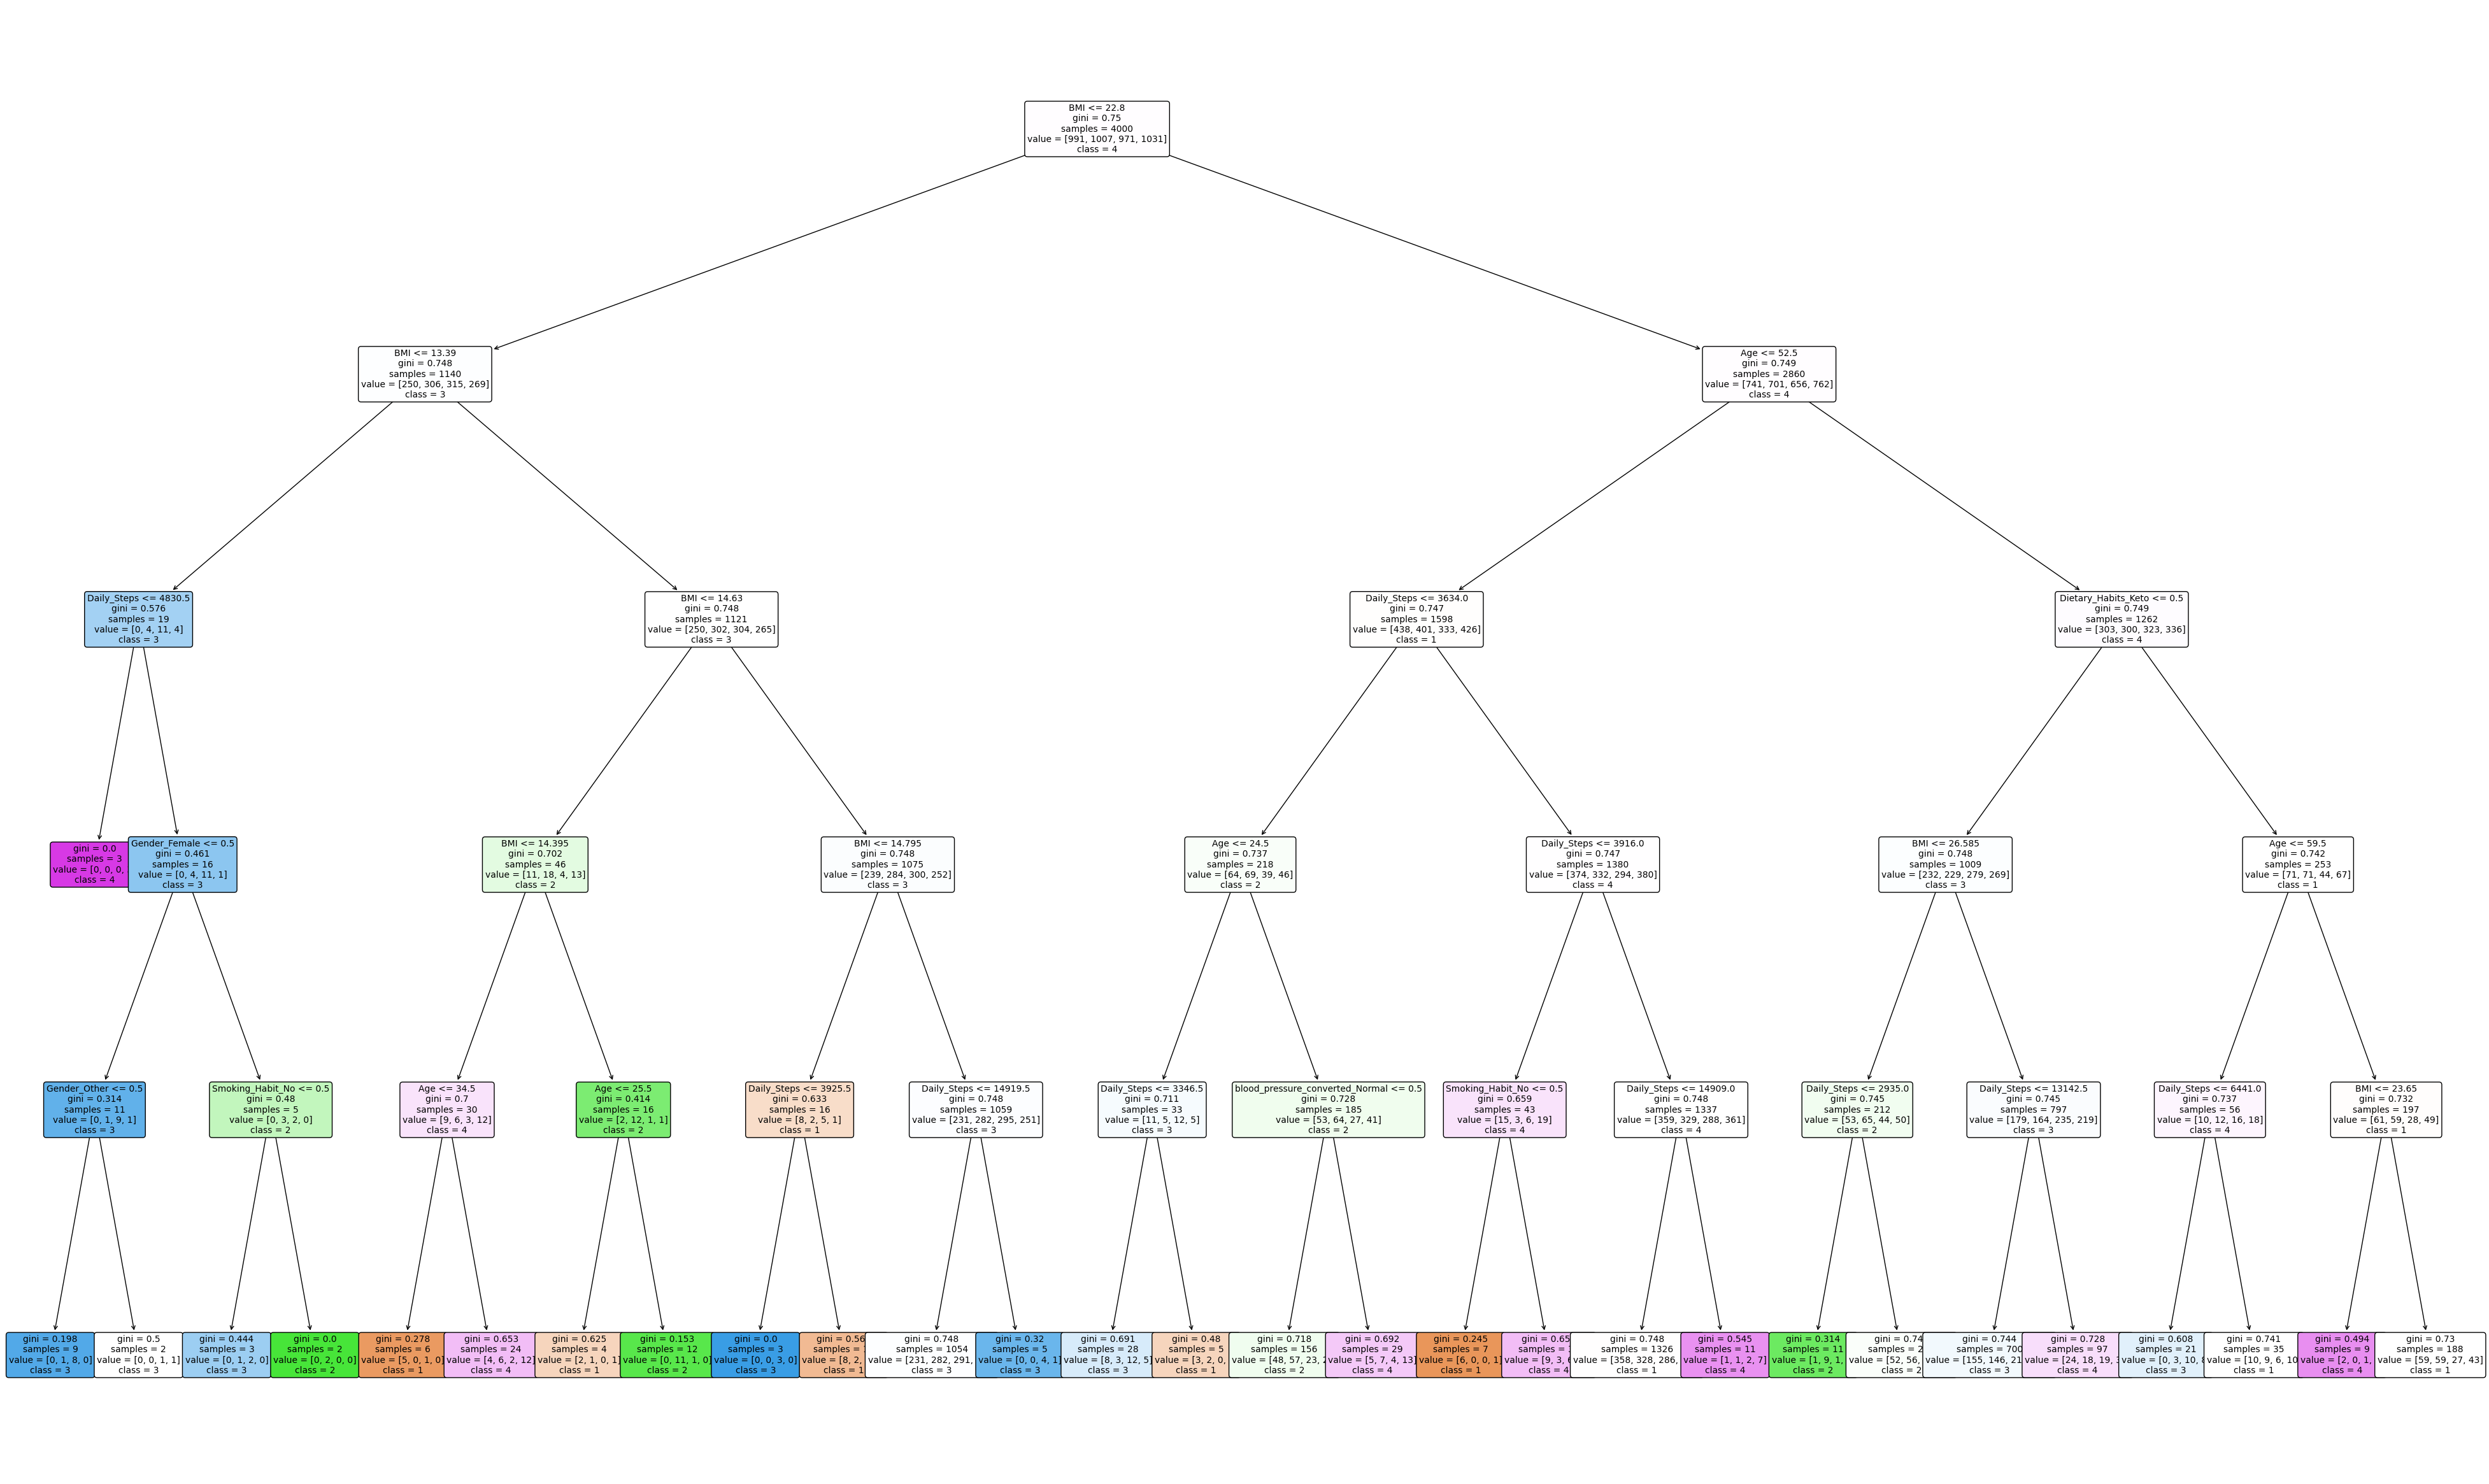

In [53]:
# Plot the Decision Tree
plt.figure(figsize=(50,30), dpi = 100)
plot_tree(dt_model, feature_names=final_feature_names, class_names=[str(cls) for cls in dt_model.classes_], filled=True, rounded=True, fontsize=10)
plt.show()

Text(0.5, 0, 'Feature Importance')

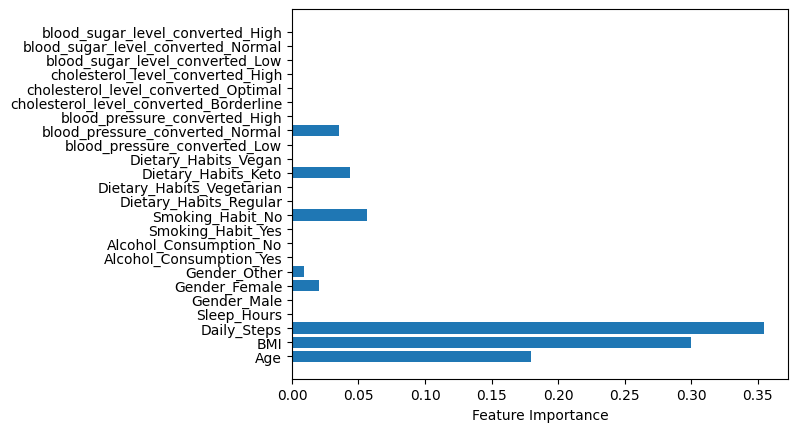

In [54]:
plt.barh(final_feature_names, dt_model.feature_importances_)
plt.xlabel("Feature Importance")

# Patient classes and inference

In [55]:
import random

class Patient:
    
    def __init__(self, name: str, 
                age: int, 
                gender: str, 
                height_cm: float, 
                weight_kg: float, 
                blood_pressure: str, 
                cholesterol_level:str, 
                blood_sugar_level: str, 
                daily_steps: int = 8400,
                sleep_hours : int = 7, 
                alcohol_consumption : bool = False, 
                smoking_habit : bool = False,
                dietary_habit: str = "Regular"
                ):
        self.name = name
        self.age = age
        self.gender = gender
        self.height_cm = height_cm
        self.weight_kg = weight_kg
        self.blood_pressure = blood_pressure
        self.cholesterol_level = cholesterol_level
        self.blood_sugar_level = blood_sugar_level
        self.daily_steps = daily_steps
        self.sleep_hours = sleep_hours
        self.alcohol_consumption = alcohol_consumption
        self.smoking_habit = smoking_habit
        self.dietary_habit = dietary_habit
        self.user_input_dict = self.__user_to_train_feature_conv()


    def __user_to_train_feature_conv(self):
        user_input_dict = {
            "Age" : self.age,
            "BMI" : raw_to_train.bmi_converter(self.height_cm, self.weight_kg),
            "Daily_Steps" : self.daily_steps,
            "Sleep_Hours" : self.sleep_hours,
            
            "Gender_Male" : 1 if self.gender == "Male" else 0,
            "Gender_Female" : 1 if self.gender == "Female" else 0,
            "Gender_Other" : 1 if self.gender == "Other" else 0,

            "Alcohol_Consumption_Yes" : 1 if self.alcohol_consumption else 0,
            "Alcohol_Consumption_No" : 0 if self.alcohol_consumption else 1,

            "Smoking_Habit_Yes" : 1 if self.smoking_habit else 0,
            "Smoking_Habit_No" : 0 if self.smoking_habit else 1,

            "Dietary_Habits_Regular" : 1 if self.dietary_habit == "Regular" else 0,
            "Dietary_Habits_Vegetarian" : 1 if self.dietary_habit == "Vegetarian" else 0,
            "Dietary_Habits_Keto" : 1 if self.dietary_habit == "Keto" else 0,
            "Dietary_Habits_Vegan" : 1 if self.dietary_habit == "Keto" else 0,
            
            "blood_pressure_converted_Low" : 1 if self.blood_pressure == "Low" else 0,
            "blood_pressure_converted_Normal" : 1 if self.blood_pressure == "Normal" else 0,
            "blood_pressure_converted_High" : 1 if self.blood_pressure == "High" else 0,
            
            
            "cholesterol_level_converted_Borderline" : 1 if self.cholesterol_level == "Borderline" else 0,
            "cholesterol_level_converted_Optimal" : 1 if self.cholesterol_level == "Optimal" else 0,
            "cholesterol_level_converted_High" : 1 if self.cholesterol_level == "High" else 0,
            

            "blood_sugar_level_converted_Low" : 1 if self.blood_sugar_level == "Low" else 0,
            "blood_sugar_level_converted_Normal" : 1 if self.blood_sugar_level == "Normal" else 0,
            "blood_sugar_level_converted_High" : 1 if self.blood_sugar_level == "High" else 0
        }

        return user_input_dict
    
    def recommend_diet(self):
        user_input_df = pd.DataFrame(self.user_input_dict, index = [0])
        prediction = dt_model.predict(user_input_df)
        
        return target_label_converter.convert_index_to_label(prediction)

    def get_food_recommendation(self, diet_type: str):
        diet = {
            "Balanced Diet": {
                "Vegetables": ["Sweet Potatoes", "Green Beans", "Broccoli", "Carrots"],
                "Fruits": ["Apple", "Banana", "Orange", "Kiwi"],
                "Protein": ["Chicken Breast", "Salmon", "Tofu", "Almonds"],
                "Carbohydrates": ["Barley", "Whole-Grain Breads", "Oats", "Brown Rice"],
                "Dairy": ["Milk", "Buttermilk", "Yogurt", "Whey Protein"],
                "Fats": ["Avocado", "Fatty Fish", "Flaxseeds", "Olive Oil"],
            },
            "Low-Carb Diet": {
                "Vegetables": ["Lettuce", "Asparagus", "Cucumbers", "Bell Peppers"],
                "Fruits": ["Olives", "Avacoado", "Orange", "Raspberries"],
                "Protein": ["Turkey Meat", "Tofu", "Eggs", "Hemp Seeds"],
                "Carbohydrates": ["Zucchini", "Cauliflower", "Kale", "Tomatoes"],
                "Dairy": ["Cream Cheese", "Heavy Cream", "Greek Yogurt", "Hard Cheeses"],
                "Fats": ["Avocado", "Walnuts", "Chia Seeds", "Sunflower Seeds"],
            },
            "High-Protein Diet": {
                "Vegetables": ["Brussels Sprouts", "Broccoli", "Spinach", "Chickpeas"],
                "Fruits": ["Guava", "Avocado", "Jackfruit", "Blackberries"],
                "Protein": ["Lentils", "Salmon", "Tofu", "Chicken Breast"],
                "Carbohydrates": ["Buckwheat", "Whole Wheat Grains", "Tofu", "Lentils"],
                "Dairy": ["Milk", "Cottage Cheese", "Yogurt", "Casein Protein Powder"],
                "Fats": ["Avocado", "Walnuts", "Chia Seeds", "Dark Chocolate"],
            },
            "Low-Fat Diet": {
                "Vegetables": ["Turnips", "Broccoli", "Green Leafy Veggies", "Bok Choy"],
                "Fruits": ["Apple", "Banana", "Watermelon", "Strawberry"],
                "Protein": ["Chicken Breast", "Mushrooms", "Egg Whites", "Legumes"],
                "Carbohydrates": ["Rice Cakes", "Air-Popped Popcorn", "Brown Rice", "Oats"],
                "Dairy": ["Skim", "Cottage Cheese", "Low-Fat Yogurt", "Cream Cheese"],
                "Fats": ["Trouts", "Cod", "Salmon", "Coconut"],
            },
        }
    
        recommended_foods = []
        for _, items in diet[diet_type].items():
            if len(items):
                # recommended_foods[category] = random.choice(items)
                recommended_foods.append(random.choice(items))
    
        return recommended_foods
    
    def get_original_values(self):
        """Extracts the original values only"""
        
        original_values = {
            "Age": self.age,
            "Height_cm": self.height_cm,
            "Weight_kg" : self.weight_kg,
            "BMI": raw_to_train.bmi_converter(self.height_cm, self.weight_kg),
            "Daily_Steps": self.daily_steps,
            "Sleep_Hours": self.sleep_hours,
            "Gender": self.gender,
            "Alcohol_Consumption": "Yes" if self.alcohol_consumption else "No",
            "Smoking_Habit": "Yes" if self.smoking_habit else "No",
            "Dietary_Habits": self.dietary_habit,
            "blood_pressure_converted": self.blood_pressure,
            "cholesterol_level_converted": self.cholesterol_level,
            "blood_sugar_level_converted": self.blood_sugar_level
        }

        return original_values
    
    def locate_patient(self):
        numerical_cols = processed_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
        categorical_cols = processed_df.select_dtypes(include=['object']).columns.tolist()
        all_columns = numerical_cols + categorical_cols

        user_values = self.get_original_values()

        num_plots = len(all_columns)
        num_cols = 3
        num_rows = math.ceil(num_plots / num_cols)

        fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 5 * num_rows))
        axes = axes.flatten()

        for i, col in enumerate(all_columns):
            patient_value = user_values.get(col, None)

            if col in numerical_cols:
                sns.histplot(processed_df[col], bins=20, kde=True, color='skyblue', edgecolor='black', ax=axes[i])
                
                if patient_value is not None:
                    axes[i].axvline(x=patient_value, color='red', linestyle='dashed', linewidth=2)
                    axes[i].text(patient_value, axes[i].get_ylim()[1] * 0.9, f'{self.name}: {patient_value}', color='red', fontsize=10)
            
            else:  # forCategorical data
                sns.countplot(x=processed_df[col], hue=processed_df[col], palette="viridis", legend=False, ax=axes[i])
                axes[i].tick_params(axis='x', rotation=45)
                
                unique_values_this = processed_df[col].unique()
                if patient_value in unique_values_this:
                    patient_index = list(unique_values_this).index(patient_value)
                    axes[i].axvline(x=patient_index, color='red', linestyle='dashed', linewidth=2)
                    axes[i].text(patient_value, axes[i].get_ylim()[1] * 0.9, f'{self.name}: {patient_value}', color='red', fontsize=10)

            axes[i].set_title(f"Distribution of {col}")
            axes[i].set_xlabel(col)
            axes[i].set_ylabel("Count" if col in categorical_cols else "Density")

        #Removing unsed sbplots
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        
        return plt
        

## Creating patient instance and performing operations

In [56]:
patient1 = Patient(
    name="TestUser",
    age = 20, 
    gender  = "Male", 
    height_cm = 150, 
    weight_kg = 68, 
    blood_pressure = "Normal", 
    cholesterol_level = "Optimal", 
    blood_sugar_level = "Normal", 
    )

In [57]:
patient1.user_input_dict

{'Age': 20,
 'BMI': 30.22222222222222,
 'Daily_Steps': 8400,
 'Sleep_Hours': 7,
 'Gender_Male': 1,
 'Gender_Female': 0,
 'Gender_Other': 0,
 'Alcohol_Consumption_Yes': 0,
 'Alcohol_Consumption_No': 1,
 'Smoking_Habit_Yes': 0,
 'Smoking_Habit_No': 1,
 'Dietary_Habits_Regular': 1,
 'Dietary_Habits_Vegetarian': 0,
 'Dietary_Habits_Keto': 0,
 'Dietary_Habits_Vegan': 0,
 'blood_pressure_converted_Low': 0,
 'blood_pressure_converted_Normal': 1,
 'blood_pressure_converted_High': 0,
 'cholesterol_level_converted_Borderline': 0,
 'cholesterol_level_converted_Optimal': 1,
 'cholesterol_level_converted_High': 0,
 'blood_sugar_level_converted_Low': 0,
 'blood_sugar_level_converted_Normal': 1,
 'blood_sugar_level_converted_High': 0}

In [58]:
patient1_diet_recommeded = patient1.recommend_diet()
patient1_diet_recommeded


['Balanced Diet']

In [59]:
recommended_food = patient1.get_food_recommendation(patient1_diet_recommeded[0])
print(f"Recommended foods for {patient1_diet_recommeded[0]} are:")
recommended_food

Recommended foods for Balanced Diet are:


['Carrots', 'Apple', 'Salmon', 'Oats', 'Milk', 'Flaxseeds']

## Visualizing patient where he/she locates

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.10/dist-packages/matplotlib/pyplot.py'>

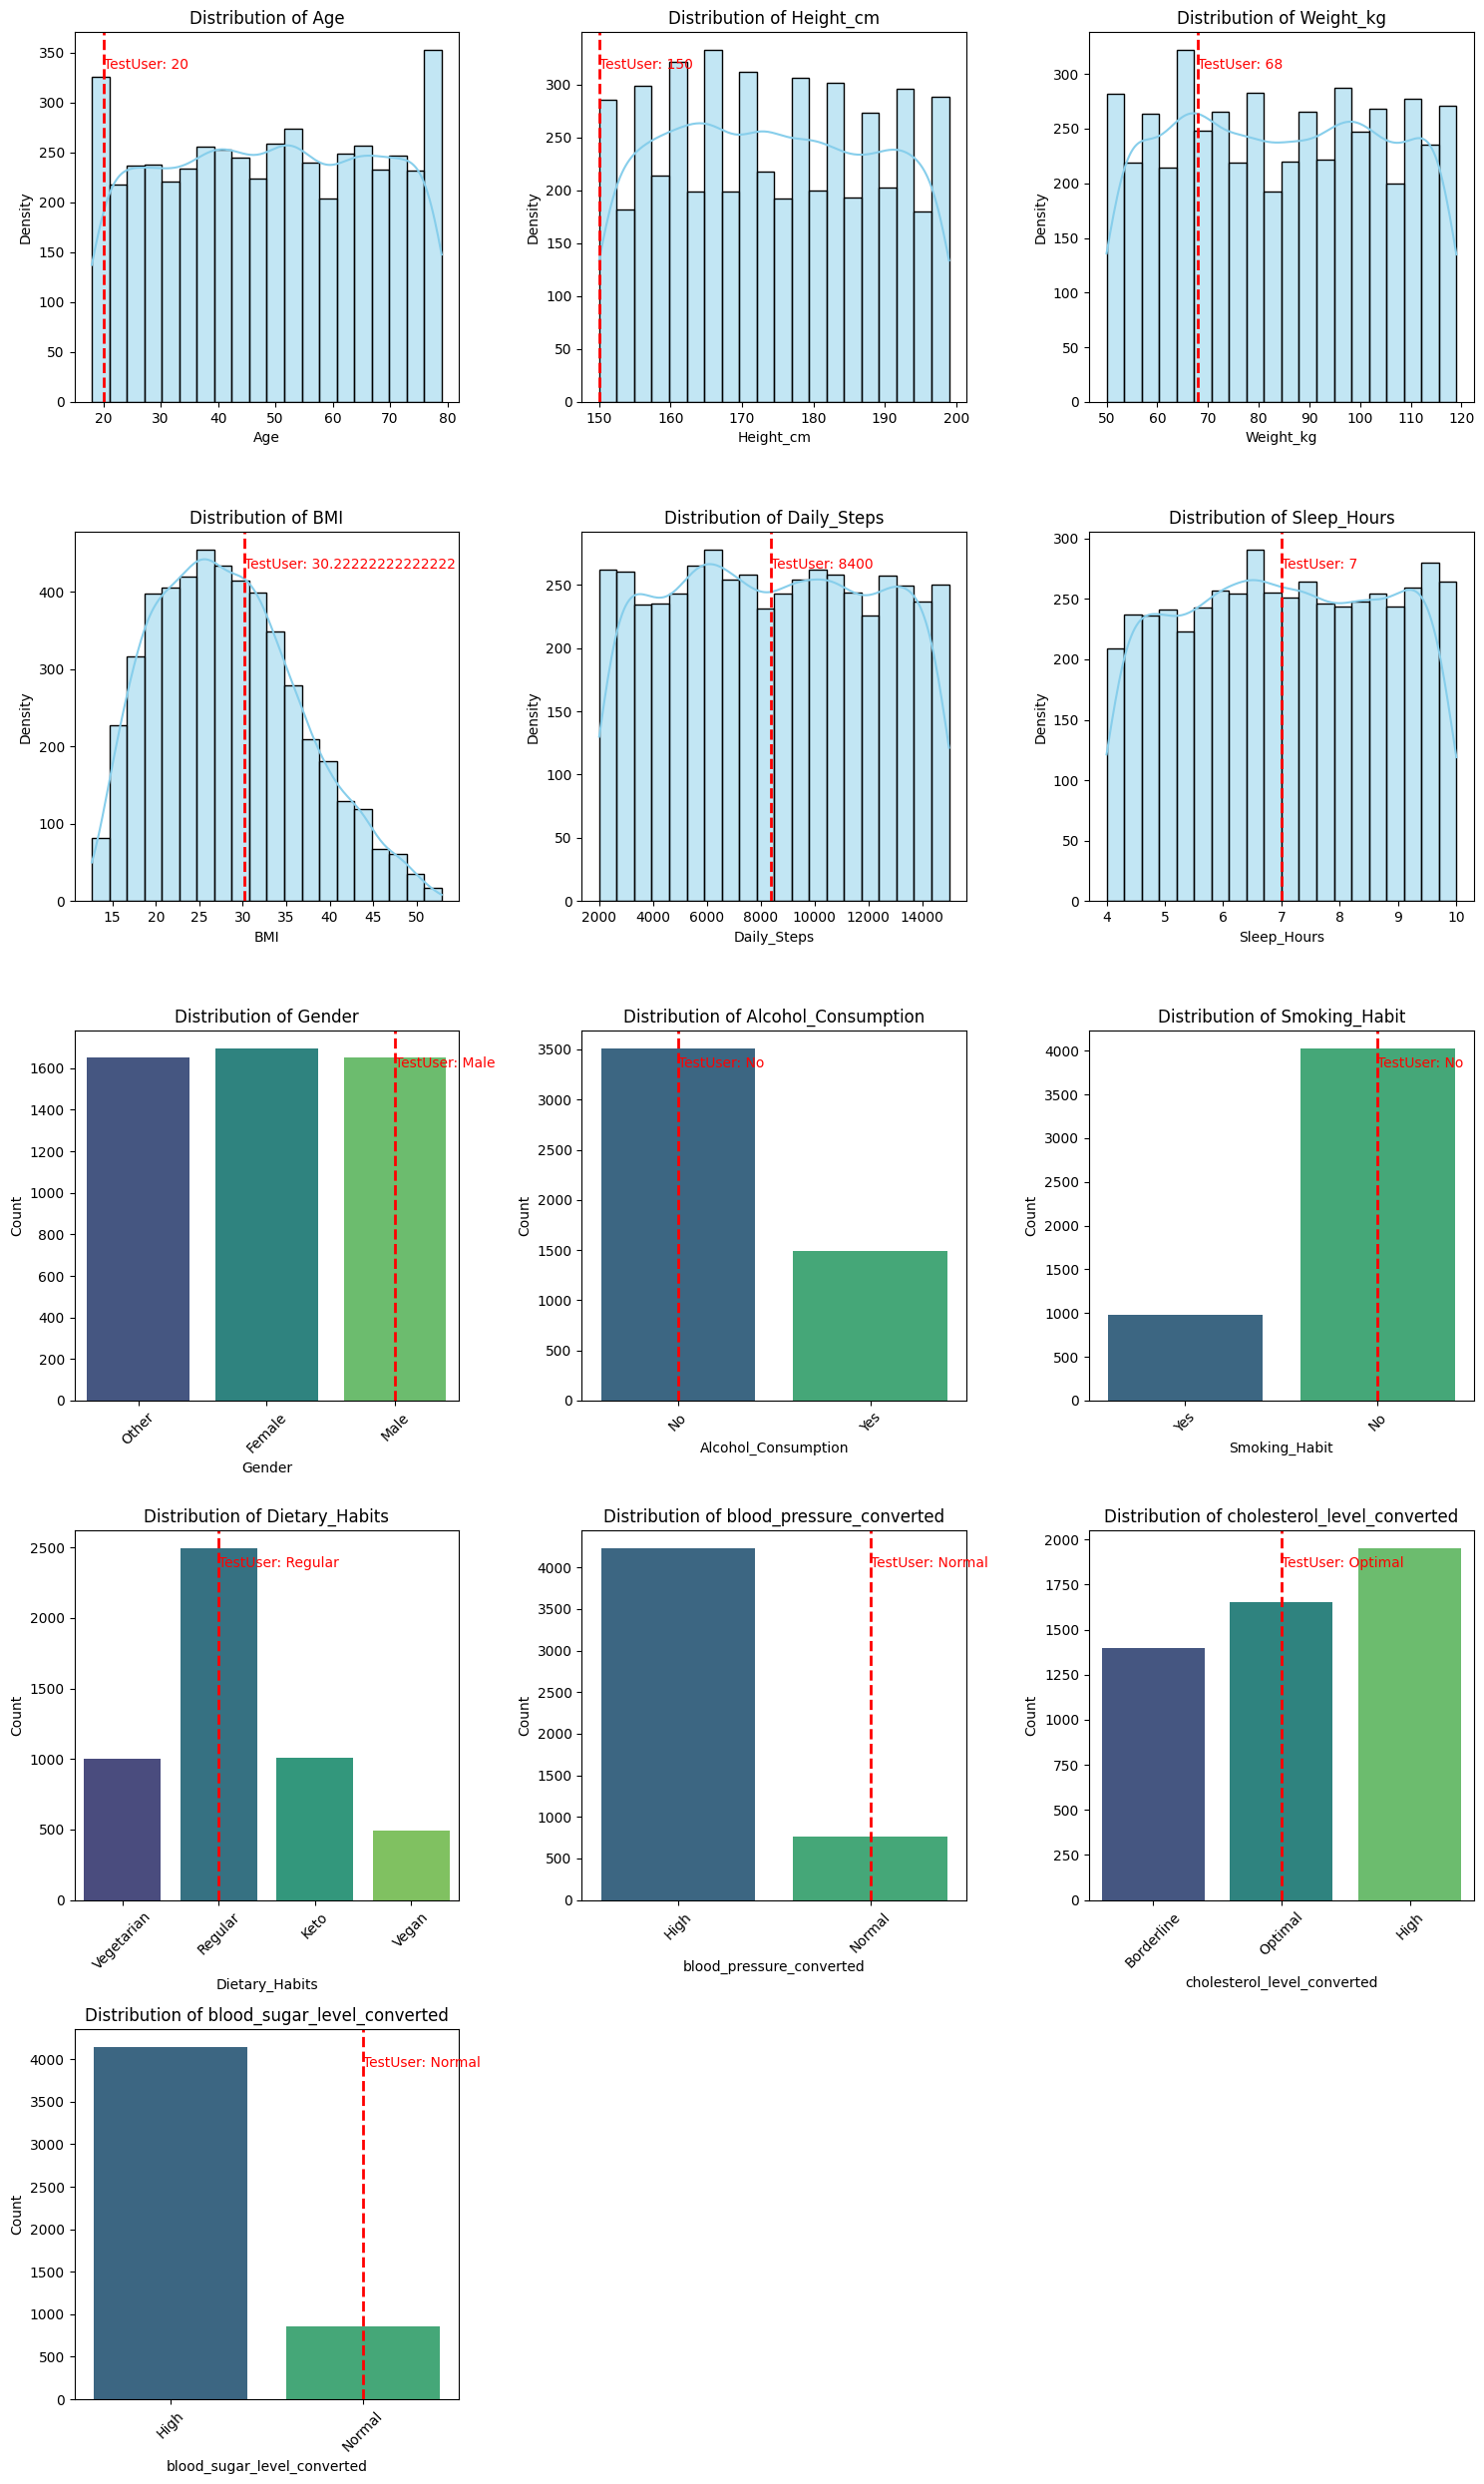

In [60]:
patient1.locate_patient()